# Filter multisensor data

> This module groups all the functions used to filter data based in other sensor data

In [ ]:
#| default_exp data.filter

In [ ]:
#| export
#| hide
import pandas as pd
import xarray as xr

from raincell.data.merge import get_link_centers_opensense_v2, get_gauge_coords, haversine_distance

In [ ]:
#| hide
# Libraries for testing and visualization
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from raincell.sample import open_cml_sample, open_gauge_sample
from nbdev.showdoc import *

## Gauges

Check the Sample data doc page to see how `cml` and `gauges` datasets are structured and what variables they contain.

In [ ]:
cml, gauges = open_cml_sample(),open_gauge_sample()

#### Nearest gauge to link path center

In [ ]:
#| hide
links_df = get_link_centers_opensense_v2(cml)
links_df.head(2)

,lat,lon
cml_id,,
3.984686N-9.789517E,3.984686,9.789517
3.985691N-9.801648E,3.985691,9.801648


In [ ]:
#| hide
link = links_df.iloc[0]
link

lat    3.984686
lon    9.789517
Name: 3.984686N-9.789517E, dtype: float64

In [ ]:
#| hide
gauge_coords = get_gauge_coords(gauges)
gauge_coords.head(2)

,lat,lon
id,,
Campus_2_Universite,4.056639,9.742334
Ecole_Saint_Andre_PK11,4.056870,9.781641


In [ ]:
#| hide
distances = gauge_coords.apply(haversine_distance, axis=1, point2=link)
distances.sort_values()

id
Lycee_NYALLA                  5.612400
Ecole_Saint_Andre_PK11        8.029850
SOCATUR                       8.475717
Meteo_IUT                     9.381050
Campus_2_Universite           9.526730
Piscine_CITE_SIC              9.896087
Eglise_Pie_X_PK14            10.461697
Hopital_des_Soeurs_Logpom    10.654718
dtype: float64

In [ ]:
#| hide
distances.min()

5.612399946399526

In [ ]:
#| hide
nearest_gauge = distances.idxmin()
nearest_gauge

'Lycee_NYALLA'

In [ ]:
#| hide
max_distance = 4 # km
in_range_gauges = [cml_id for cml_id, l in links_df.iterrows() if gauge_coords.apply(haversine_distance, axis=1, point2=l).min() <= max_distance]
in_range_gauges[:4]

['3.996996N-9.761328E',
 '4.007006N-9.767519E',
 '4.008236N-9.788792E',
 '4.013180N-9.765819E']

In [ ]:
#| hide
cml.cml_id.size

126

In [ ]:
#| hide
cml.sel(cml_id=in_range_gauges).cml_id.size

108

In [ ]:
#| export
def filter_by_distance_to_nearest_gauge(
        cml: xr.Dataset, # CML dataset containing link information with coordinates
        gauges: xr.Dataset, # Dataset containing rain gauge locations
        mx_dist: float, # Maximum allowed distance (in km) from a link center to its nearest gauge. Links farther than this are filtered out.
        gauge_lat: str = "lat", # Name of the latitude coordinate in the gauges dataset
        gauge_lon: str = "lon" # Name of the longitude coordinate in the gauges dataset
    ) -> xr.Dataset: # Filtered CML dataset, containing only links whose center is within `mx_dist` km of at least one gauge
    """Filter CML links based on their distance to the nearest rain gauge."""
    link_centers = get_link_centers_opensense_v2(cml)
    gauge_coords = get_gauge_coords(gauges, lat=gauge_lat, lon=gauge_lon)
    
    in_range = [cml_id for cml_id, link in link_centers.iterrows() if gauge_coords.apply(haversine_distance, axis=1, point2=link).min() <= mx_dist]
    return cml.sel(cml_id=in_range)

In [ ]:
filtered_cml = filter_by_distance_to_nearest_gauge(cml, gauges, 2.5)
filtered_cml

<xarray.Dataset> Size: 62MB
Dimensions:      (cml_id: 72, sublink_id: 6, time: 2964)
Coordinates: (10)
Data variables:
    rsl_avg      (cml_id, sublink_id, time) float64 10MB -54.1 -54.1 ... nan nan
    tsl_avg      (cml_id, sublink_id, time) float64 10MB 10.5 10.5 ... nan nan
    rsl_min      (cml_id, sublink_id, time) float64 10MB -54.3 -54.3 ... nan nan
    tsl_min      (cml_id, sublink_id, time) float64 10MB 10.5 10.5 ... nan nan
    rsl_max      (cml_id, sublink_id, time) float64 10MB -53.8 -53.8 ... nan nan
    tsl_max      (cml_id, sublink_id, time) float64 10MB 10.5 10.5 ... nan nan
Attributes:
    title:                 East side Douala CML links sample data
    file author(s):        Orange Cameroun and IRD Rainsmore Group
    institution:           Orange Cameroun and IRD Rainsmore Group
    date:                  2025-11-07
    source:                Modified Orange Cameroun CML data for example purp...
    naming convention:     COST ACTION OPENSENSE V2
    license restrictions:  CC BY-NC-ND 4.0

In [ ]:
#| hide
#| eval: false
links = cml.cml_id.to_dataframe()
links_geo = gpd.GeoDataFrame(index=links.index, geometry=[LineString([(r.site_0_lon, r.site_0_lat), (r.site_1_lon, r.site_1_lat)]) for idx, r in links.iterrows()])
links_geo.head(2)

,geometry
cml_id,
3.984686N-9.789517E,"LINESTRING (9.78717 3.99272, 9.79187 3.97665)"
3.985691N-9.801648E,"LINESTRING (9.78717 3.99272, 9.81613 3.97866)"


In [ ]:
#| hide
#| eval: false
filt_links = filtered_cml.cml_id.to_dataframe()
filt_links_geo = gpd.GeoDataFrame(index=filt_links.index, geometry=[LineString([(r.site_0_lon, r.site_0_lat), (r.site_1_lon, r.site_1_lat)]) for idx, r in filt_links.iterrows()])
filt_links_geo.head(2)

,geometry
cml_id,
4.013180N-9.765819E,"LINESTRING (9.76783 4.029, 9.76381 3.99736)"
4.015776N-9.756458E,"LINESTRING (9.76783 4.029, 9.74508 4.00255)"


In [ ]:
#| hide
#| eval: false
gauge_geo = gpd.GeoDataFrame(index=gauge_coords.index, geometry=gpd.points_from_xy(gauge_coords.lon, gauge_coords.lat))
gauge_geo.head(2)

,geometry
id,
Campus_2_Universite,POINT (9.74233 4.05664)
Ecole_Saint_Andre_PK11,POINT (9.78164 4.05687)


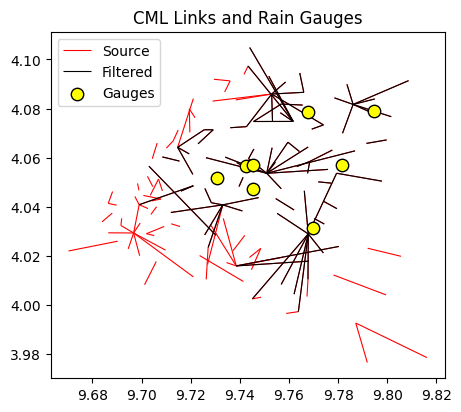

In [ ]:
#| code-fold: true
links = cml.cml_id.to_dataframe()
links_geo = gpd.GeoDataFrame(index=links.index, geometry=[LineString([(r.site_0_lon, r.site_0_lat), (r.site_1_lon, r.site_1_lat)]) for idx, r in links.iterrows()])
filt_links = filtered_cml.cml_id.to_dataframe()
filt_links_geo = gpd.GeoDataFrame(index=filt_links.index, geometry=[LineString([(r.site_0_lon, r.site_0_lat), (r.site_1_lon, r.site_1_lat)]) for idx, r in filt_links.iterrows()])
gauge_geo = gpd.GeoDataFrame(index=gauge_coords.index, geometry=gpd.points_from_xy(gauge_coords.lon, gauge_coords.lat))

fig, ax = plt.subplots(figsize=(6, 4.5))
links_geo.plot(ax=ax, color='red', linewidth=0.8, label="Source")
filt_links_geo.plot(ax=ax, color='black', linewidth=0.8, label="Filtered")
gauge_geo.plot(ax=ax, color='yellow', edgecolor='black', markersize=80, zorder=5, label="Gauges")
ax.legend(loc="upper left")
ax.set_title("CML Links and Rain Gauges");

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()